In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-12 21:59:15 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-12 21:59:17 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-12 21:59:17 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-12 21:59:18 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-12 21:59:18 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-12 21:59:18 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-12 21:59:18 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-12 21:59:18 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows

In [3]:
import os
import torch
torch.set_num_threads(os.cpu_count())

from src.models.lstm import LSTMForecaster
from src.training.trainer import train_model, predict

lstm_model = LSTMForecaster(num_features=X_train.shape[2])
history = train_model(lstm_model, X_train, y_train_scaled, X_val, y_val_scaled, epochs=10)
print("Retrained. Parameters:", history["num_parameters"], "| Time:", round(history["training_time_seconds"], 1), "s")

2026-09-12 21:59:58 | INFO     | src.training.trainer | Training LSTMForecaster | 23576 parameters | device=cpu
2026-09-12 21:59:58 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 22:00:39 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 22:00:53 | INFO     | src.training.trainer | Epoch 1/10 | train_loss=0.057105 | val_loss=0.015987
2026-09-12 22:00:53 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 22:01:27 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 22:01:39 | INFO     | src.training.trainer | Epoch 2/10 | train_loss=0.007468 | val_loss=0.007265
2026-09-12 22:01:39 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 22:02:10 | INFO     | src.training.trainer |   batch 100/131
2026-09-12 22:02:24 | INFO     | src.training.trainer | Epoch 3/10 | train_loss=0.004645 | val_loss=0.004903
2026-09-12 22:02:24 | INFO     | src.training.trainer |   batch 0/131
2026-09-12 22:02:55 | INFO     | src.training.trainer |   batch 1

In [4]:
from src.preprocessing import inverse_transform_column
from src.anomaly.detector import compute_residuals, detect_anomalies
from src.config import TARGET_COL

y_pred_test_scaled = predict(lstm_model, X_test)

y_true_full = inverse_transform_column(y_test_scaled, scaler, scale_columns, TARGET_COL)
y_pred_full = inverse_transform_column(y_pred_test_scaled, scaler, scale_columns, TARGET_COL)

# Use only horizon step 1 (hour+1 ahead) for a clean chronological residual series
y_true_h1 = y_true_full[:, 0]
y_pred_h1 = y_pred_full[:, 0]

residuals = compute_residuals(y_true_h1, y_pred_h1)
print("Residuals shape:", residuals.shape)
print("Residual stats: mean=%.2f, std=%.2f" % (residuals.mean(), residuals.std()))

Residuals shape: (7087,)
Residual stats: mean=-5.68, std=85.13


In [5]:
anomaly_results = detect_anomalies(residuals, window=168, z_threshold=3.0)
print(anomaly_results["is_anomaly"].value_counts())
print("\nFlagged anomalies:")
print(anomaly_results[anomaly_results["is_anomaly"]])

2026-09-12 22:07:42 | INFO     | src.anomaly.detector | Anomaly detection: 49/7087 points flagged (0.69%) at |z| > 3.0, window=168
is_anomaly
False    7038
True       49
Name: count, dtype: int64

Flagged anomalies:
        residual  rolling_mean  rolling_std   z_score  is_anomaly
185  -143.390669      7.855341    41.209442 -3.670179        True
615  -152.389495     23.872030    41.716327 -4.225241        True
616  -172.184591     22.625081    43.796277 -4.448088        True
617  -205.680620     21.273258    46.230725 -4.909157        True
618  -167.642091     19.858777    49.426873 -3.793500        True
619  -165.244218     18.509249    51.405168 -3.574611        True
620  -144.318831     16.965556    52.991224 -3.043606        True
622  -154.295730     14.112767    54.646856 -3.081760        True
788   151.505890     -4.847779    50.516448  3.095104        True
1124  129.669078     -5.534723    38.233685  3.536248        True
1338 -252.929831     14.821188    39.025716 -6.860887     

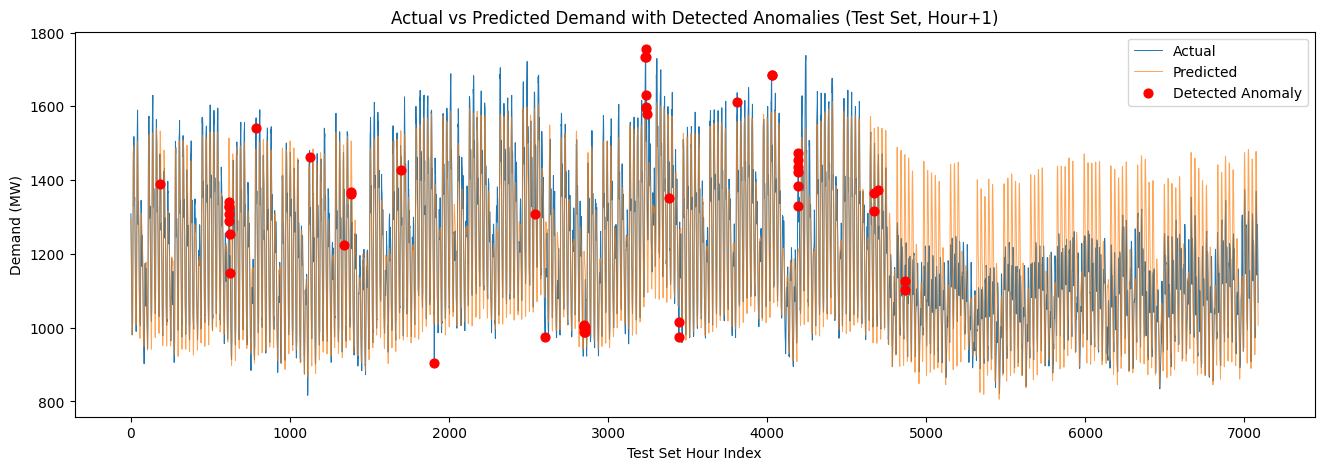

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_true_h1, label="Actual", linewidth=0.7)
ax.plot(y_pred_h1, label="Predicted", linewidth=0.7, alpha=0.7)

anomaly_idx = anomaly_results[anomaly_results["is_anomaly"]].index
ax.scatter(anomaly_idx, y_true_h1[anomaly_idx], color="red", s=40, zorder=5, label="Detected Anomaly")

ax.set_title("Actual vs Predicted Demand with Detected Anomalies (Test Set, Hour+1)")
ax.set_xlabel("Test Set Hour Index")
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

In [7]:
import json
from pathlib import Path

experiments_path = Path.cwd().parent / "experiments" / "anomaly_detection_summary.json"

summary = {
    "window": 168,
    "z_threshold": 3.0,
    "total_points": len(anomaly_results),
    "anomalies_flagged": int(anomaly_results["is_anomaly"].sum()),
    "anomaly_rate_pct": round(100 * anomaly_results["is_anomaly"].sum() / len(anomaly_results), 3),
    "residual_mean": float(residuals.mean()),
    "residual_std": float(residuals.std()),
    "largest_anomaly_index": int(anomaly_results["residual"].abs().idxmax()),
    "largest_anomaly_residual": float(anomaly_results.loc[anomaly_results["residual"].abs().idxmax(), "residual"]),
}

with open(experiments_path, "w") as f:
    json.dump(summary, f, indent=2)

anomaly_results.to_csv(Path.cwd().parent / "experiments" / "anomaly_detection_full.csv")
print("Saved anomaly_detection_summary.json and anomaly_detection_full.csv")
print(json.dumps(summary, indent=2))

Saved anomaly_detection_summary.json and anomaly_detection_full.csv
{
  "window": 168,
  "z_threshold": 3.0,
  "total_points": 7087,
  "anomalies_flagged": 49,
  "anomaly_rate_pct": 0.691,
  "residual_mean": -5.675355021185774,
  "residual_std": 85.13259439189427,
  "largest_anomaly_index": 5320,
  "largest_anomaly_residual": -367.3402810996233
}


In [8]:
print(anomaly_results.loc[5320])
print("\nContext window before this point:")
print(anomaly_results.loc[5300:5320])

residual       -367.340281
rolling_mean    -21.089804
rolling_std     120.436871
z_score          -2.874954
is_anomaly           False
Name: 5320, dtype: object

Context window before this point:
        residual  rolling_mean  rolling_std   z_score  is_anomaly
5300  -81.072219    -13.933428   119.909009 -0.559914       False
5301 -102.342491    -14.087022   119.978778 -0.735592       False
5302  -95.044001    -14.272075   120.091402 -0.672587       False
5303  -32.220155    -14.291337   120.104171 -0.149277       False
5304    7.583173    -14.355586   120.110898  0.182654       False
5305    5.319500    -14.551347   120.047789  0.165524       False
5306   17.035111    -14.905050   119.900214  0.266390       False
5307   26.947097    -15.256026   119.718686  0.352519       False
5308   30.045671    -15.707712   119.413251  0.383152       False
5309    6.113237    -16.188710   119.062640  0.187313       False
5310  -11.863193    -16.739161   118.742158  0.041064       False
5311  -13.33

In [ ]:
import json
import numpy as np
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data, chronological_split, fit_scaler, apply_scaler, inverse_transform_column
from src.feature_engineering import build_features
from src.sequence_builder import create_sequences_for_all_splits
from src.evaluation.metrics import evaluate_all
from src.config import MODEL_FEATURE_COLUMNS, TARGET_COL, DEFAULT_LOOKBACK, FORECAST_HORIZON

DEV_LOOKBACK = 72  # temporary, for fast iteration — NOT the final 168

df_raw = load_raw_data()
df_clean = clean_raw_data(df_raw)
df_features = build_features(df_clean)
splits = chronological_split(df_features)

scale_columns = MODEL_FEATURE_COLUMNS + [TARGET_COL]
scaler = fit_scaler(splits.train, scale_columns)

train_scaled = apply_scaler(splits.train, scaler, scale_columns)
val_scaled = apply_scaler(splits.val, scaler, scale_columns)
test_scaled = apply_scaler(splits.test, scaler, scale_columns)

sequences = create_sequences_for_all_splits(train_scaled, val_scaled, test_scaled, MODEL_FEATURE_COLUMNS)
X_train, y_train_scaled = sequences["train"]
X_val, y_val_scaled = sequences["val"]
X_test, y_test_scaled = sequences["test"]

print("Ready:", X_train.shape, X_val.shape, X_test.shape)

2026-09-11 11:09:18 | INFO     | src.data_loader | Loading raw dataset from C:\Users\Ram\OneDrive\Desktop\energy-demand-lstm\data\raw\continuous_dataset.csv
2026-09-11 11:09:19 | INFO     | src.data_loader | Loaded raw dataset: 48048 rows, 17 columns
2026-09-11 11:09:19 | INFO     | src.preprocessing | Cleaning complete: 48048 rows, 4 flagged as diagnostic extreme events (|z| > 4.0)
2026-09-11 11:09:20 | INFO     | src.feature_engineering | Added national weather averages: temp_avg, humidity_avg, precip_avg, wind_avg
2026-09-11 11:09:20 | INFO     | src.feature_engineering | Added calendar features and cyclical encodings
2026-09-11 11:09:20 | INFO     | src.feature_engineering | Added lag features: ['lag_1', 'lag_24', 'lag_48', 'lag_168']
2026-09-11 11:09:20 | INFO     | src.feature_engineering | Added rolling features: rolling_mean_24, rolling_std_24, rolling_mean_168
2026-09-11 11:09:20 | INFO     | src.feature_engineering | Feature engineering complete: 48048 rows before, 47880 rows